## Neural Network Model #1: **Multi-Layer Perceptron**

First, we will import our pre-split and scaled training, validation, and test sets.

In [1]:
import pandas as pd
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training


In predicting urban and rural households, we employ a multi-layer perceptron. To get more effective final model, we accomplish the following:

1. Preliminary comparison of different neural network architectures
2. Comparison of hyperparameter configurations of the selected architecture(s)
3. Error analysis of the selected model and tuning

In [ ]:
from MCO_functions import trainNetwork, evaluateNetwork

# Ensure deterministic behavior for reproducibility
import torch, numpy as np, random, os

# load data into PyTorch tensors
nn_X_train = torch.from_numpy(X_train_scaled.to_numpy()).float()
nn_y_train = torch.from_numpy(y_train.to_numpy()).long()

nn_X_val = torch.from_numpy(X_val_scaled.to_numpy()).float()
nn_y_val = torch.from_numpy(y_val.to_numpy()).long()

### Preliminary Comparison of different Neural Network Architectures

Rectified Linear Units (ReLu) is used as the activation function in training the neural networks for its less expensive computation compared to sigmoid.  

$$
ReLU(x)=max(0,x)
$$

$$
f(x)=
\begin{cases}
0 & \text{if } x < 0 \\
1 & \text{if } x \geq 0 
\end{cases}
$$  

We perform an initial grid search over different possible neural network architectures and compare their performance metrics in order to get a better configuration for the final model. These architectures follow the pyramid pattern, where after the first hidden layer, each layer has half the neurons of the previous. This approach is known to be more effective for tabular data.  

https://machinelearningtheory.org/docs/Deep-Learning/designing-the-architecture/  

An initial learning rate of 0.005 and a relatively smaller epoch limit of 15 is used to speed up the preliminary search. Each network architecture is trained and evaluated using multiple seeds, with each of their resulting metrics averaged to provide more stable performance estimates.

In [ ]:
learning_rate = 0.005
# a relatively small epoch limit to prevent long training times during preliminary search
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (64, 32),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=88,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })

    # compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (64, 32), seed: 0
Epoch: 1 	Loss: 0.457854
Epoch: 2 	Loss: 0.415031
Epoch: 3 	Loss: 0.415337
Epoch: 4 	Loss: 0.412805
Epoch: 5 	Loss: 0.407758
Epoch: 6 	Loss: 0.404868
Epoch: 7 	Loss: 0.404763
Epoch: 8 	Loss: 0.398852
Epoch: 9 	Loss: 0.403813
Epoch: 10 	Loss: 0.398497
Epoch: 11 	Loss: 0.397456
Epoch: 12 	Loss: 0.395069
Epoch: 13 	Loss: 0.396009
Epoch: 14 	Loss: 0.396112
Epoch: 15 	Loss: 0.397008

Training Neural Network with hidden layers: (64, 32), seed: 42
Epoch: 1 	Loss: 0.455515
Epoch: 2 	Loss: 0.417149
Epoch: 3 	Loss: 0.411581
Epoch: 4 	Loss: 0.409275
Epoch: 5 	Loss: 0.409641
Epoch: 6 	Loss: 0.406944
Epoch: 7 	Loss: 0.404119
Epoch: 8 	Loss: 0.401259
Epoch: 9 	Loss: 0.400035
Epoch: 10 	Loss: 0.398821
Epoch: 11 	Loss: 0.396254
Epoch: 12 	Loss: 0.396693
Epoch: 13 	Loss: 0.398396
Epoch: 14 	Loss: 0.396041
Epoch: 15 	Loss: 0.395669

Training Neural Network with hidden layers: (64, 32), seed: 123
Epoch: 1 	Loss: 0.454708
Epoch: 2 	Loss: 0.415

Each architecture's change in loss throughout training is visualized using a line graph.

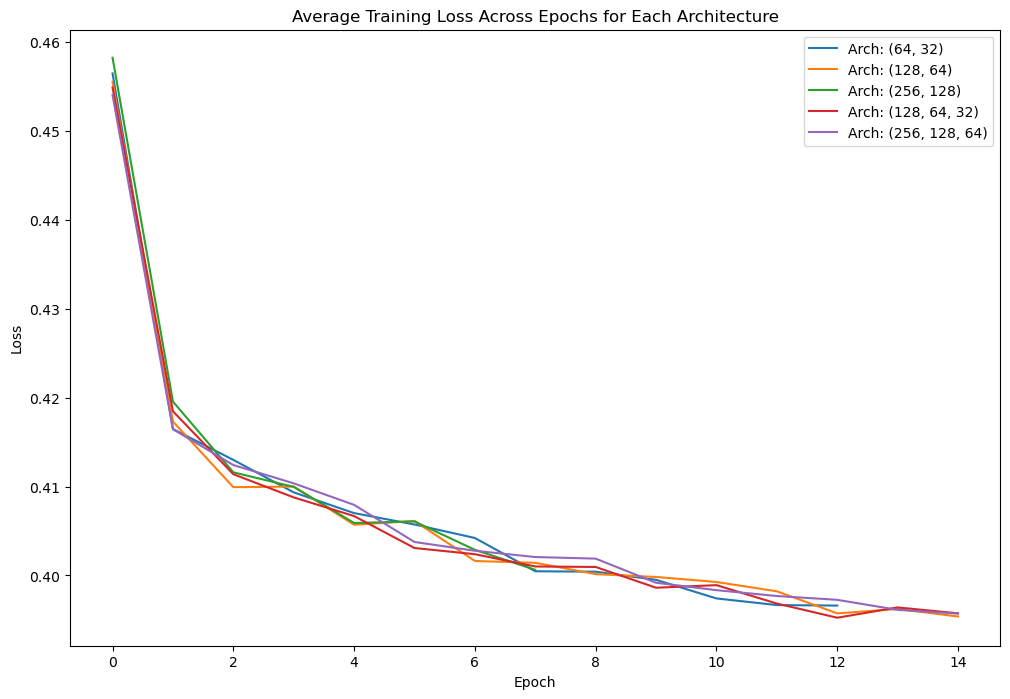

In [60]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

We observe that on or before the 15th epoch (epoch 14) the change in loss is minimal compared to the first three.

# **[5]** Error Analysis and Model Tuning

For each class, precision, recall, and f1-scores are used as metrics along with balanced accuracy. Balanced accuracy, which is the average of the recall on each class, is more effective for classification problems on imbalanced sets. Between the **urban (class 1)** and **rural (class 0)** classes in the dataset, rural is the majority class.  

$$\text{Balanced Accuracy} = \frac{1}{k} \sum_{i=1}^{k} \text{Recall}_i$$

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html

In [70]:
results_flat = []
for r in results:
    flat_r = {
        "architecture": r["architecture"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"]
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T
# results_df

,0,1,2,3,4
architecture,"(64, 32)","(128, 64)","(256, 128)","(128, 64, 32)","(256, 128, 64)"
train_accuracy,0.797042,0.800308,0.795066,0.781003,0.801648
train_precision_rural,0.826091,0.836957,0.822845,0.801209,0.83289
train_precision_urban,0.816358,0.796982,0.821761,0.863442,0.80586
train_recall_rural,0.901936,0.881334,0.906349,0.938161,0.892972
train_recall_urban,0.692148,0.719283,0.683784,0.623845,0.710324
train_f1_rural,0.861886,0.857277,0.862162,0.864136,0.861648
train_f1_urban,0.747614,0.751916,0.744751,0.723485,0.754318
val_accuracy,0.783942,0.789898,0.783196,0.772955,0.788141
val_precision_rural,0.819078,0.831594,0.816845,0.797678,0.825323


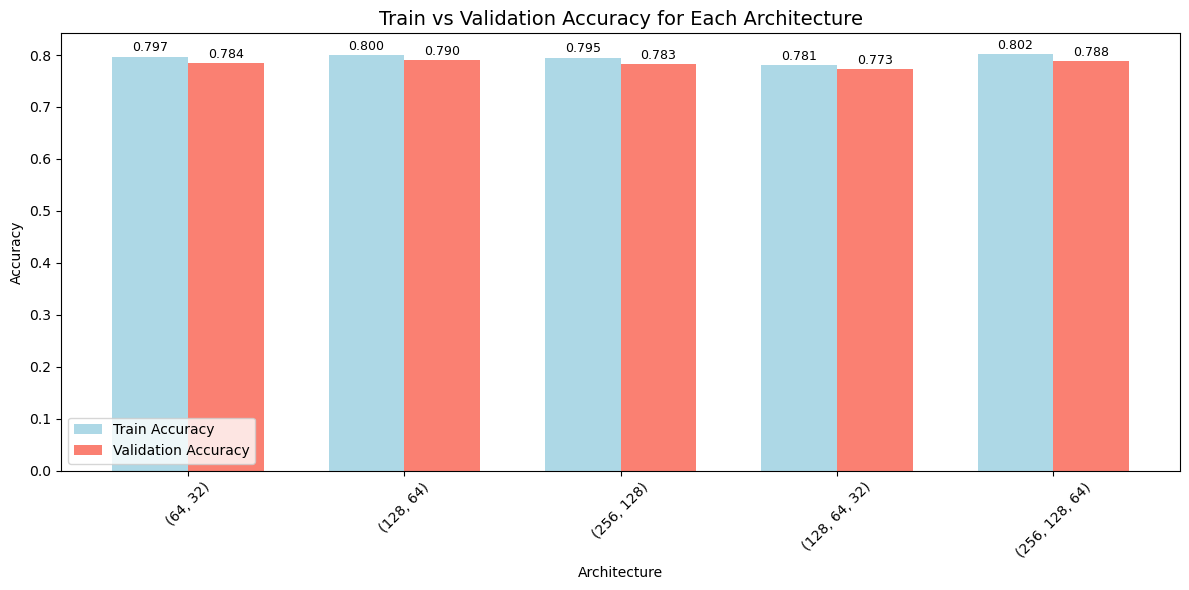

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.title("Train vs Validation Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

plt.show()

We conclude that so far none of the tested architectures are overfitting, since metrics from training and validation do not vary drastically. Moreover, among the architectures, (128,64) and (256,128,64) have the highest validation balanced accuracies of approximately 0.79. We use balanced accuracy as the primary metric for comparison because it gives equal weight to both the urban and rural classes.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html  
https://iterate.ai/ai-glossary/balanced-accuracy  

By the principle of Occam's Razor, it is therefore justified to select the neural network with the lesser neurons among them as this would lead to a similar result as the other, only with less memory consumption.

https://www.geeksforgeeks.org/machine-learning/occams-razor/

Thus, we proceed to fine tine the neural network with 2 hidden layers having a configuration of 128 and 64 neurons respectively.

# **[6]** Model Evaluation

### Comparison of different Hyperparameter Configurations

Performance of the model on different configurations of learning rates and batch sizes are compared.

In [ ]:
epoch_limit = 100

learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [32, 64, 128]

seeds = [0]  # using only one seed to save time.

# Only use one architecture
configs = [
    (128, 64)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=88,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on both train and validation sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics
                })

            # compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()}
            })


Training Neural Network with hidden layers: (128, 64), seed: 0, learning rate: 0.001, batch size: 32
Epoch: 1 	Loss: 0.448823
Epoch: 2 	Loss: 0.415411
Epoch: 3 	Loss: 0.410394
Epoch: 4 	Loss: 0.406172
Epoch: 5 	Loss: 0.404807
Epoch: 6 	Loss: 0.401788
Epoch: 7 	Loss: 0.399248
Epoch: 8 	Loss: 0.399296
Epoch: 9 	Loss: 0.399332
Epoch: 10 	Loss: 0.396055
Epoch: 11 	Loss: 0.393689
Epoch: 12 	Loss: 0.393756
Epoch: 13 	Loss: 0.393268
Epoch: 14 	Loss: 0.393070
Epoch: 15 	Loss: 0.391080
Epoch: 16 	Loss: 0.391446
Epoch: 17 	Loss: 0.389379
Epoch: 18 	Loss: 0.388670
Epoch: 19 	Loss: 0.387548
Epoch: 20 	Loss: 0.387907
Epoch: 21 	Loss: 0.386412
Epoch: 22 	Loss: 0.387701
Epoch: 23 	Loss: 0.383905
Epoch: 24 	Loss: 0.382944
Epoch: 25 	Loss: 0.383348
Epoch: 26 	Loss: 0.382093
Epoch: 27 	Loss: 0.382069
Epoch: 28 	Loss: 0.380299
Epoch: 29 	Loss: 0.380178
Epoch: 30 	Loss: 0.379335
Epoch: 31 	Loss: 0.378212
Epoch: 32 	Loss: 0.375741
Epoch: 33 	Loss: 0.376932
Epoch: 34 	Loss: 0.373162
Epoch: 35 	Loss: 0.3750

The change in training loss across epochs is visualized using a line graph. It can be seen that over 100 epochs, the configuration of learning rate = 0.001 and batch size = 128 ultimately has the greatest reduction in loss.

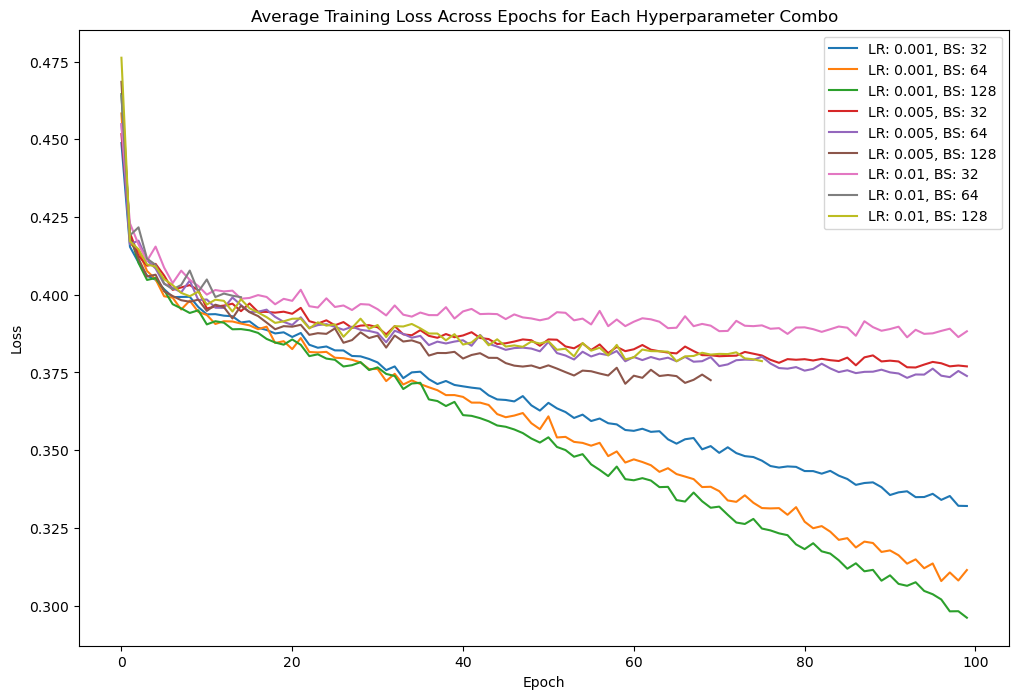

In [98]:
# graph loss history for each learning rate and batch size combination (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for lr in learning_rates:
    for bs in batch_sizes:
        # filter loss history for this learning rate and batch size
        config_history = [h for h in loss_history if h["architecture"] == (128, 64) and h["seed"] == 0 and h["learning_rate"] == lr and h["batch_size"] == bs]

        min_len = min(len(h["losses"]) for h in config_history)

        aligned_losses = [
            h["losses"][:min_len] for h in config_history
        ]
        
        # average losses across seeds
        avg_losses = np.mean(aligned_losses, axis=0)
        
        plt.plot(avg_losses, label=f"LR: {lr}, BS: {bs}")

plt.title("Average Training Loss Across Epochs for Each Hyperparameter Combo")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The metrics for comparing the different configurations are displayed in table form.

In [84]:
# compare
results_flat = []
for r in results:
    flat_r = {
        "learning_rate": r["learning_rate"],
        "batch_size": r["batch_size"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"]
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4,5,6,7,8
learning_rate,0.001000,0.001000,0.001000,0.005000,0.005000,0.005000,0.010000,0.010000,0.010000
batch_size,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000
train_accuracy,0.818984,0.852297,0.852792,0.805462,0.818023,0.781247,0.784905,0.802037,0.804433
train_precision_rural,0.836681,0.881904,0.875503,0.828113,0.850558,0.797094,0.804744,0.832662,0.826231
train_precision_urban,0.864220,0.831448,0.853000,0.840325,0.804998,0.892039,0.860315,0.805714,0.844406
train_recall_rural,0.931156,0.898721,0.915601,0.918424,0.887602,0.954373,0.936225,0.893824,0.921477
train_recall_urban,0.706812,0.805873,0.789982,0.692501,0.748443,0.608122,0.633584,0.710250,0.687390
train_f1_rural,0.881394,0.890233,0.895103,0.870933,0.868685,0.868672,0.865520,0.862160,0.871259
train_f1_urban,0.777630,0.818461,0.820283,0.759285,0.775691,0.723214,0.729744,0.754976,0.757851
val_accuracy,0.787194,0.796010,0.787531,0.788734,0.799045,0.766015,0.775419,0.790774,0.785130


Among all the configurations tested, the model trained with a learning rate of 0.005 and batch size of 64 has a high balanced accuracy of approximately 80 percent on validation, and also consistently achieved scores greater than 70 percent in other metrics.

However, the model trained with learning rate of 0.001 and batch size of 128 has a steadier and greater decrease in loss, indicating that it exhibits more stable learning. Although its validation metrics are slightly lower than the aforementioned model, they are close enough to the top performer to merit use.

Thus, due to its good validation performance and stable learning, a model with learning rate of 0.001 and batch size of 128 will be used in error analysis and further fine tuning.

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- Uses ChatGPT to clarify proper flow for training loop
- Uses ChatGPT to assist with understanding errors that came up during debugging
- Uses ChatGPT to fix python syntax for neural network implementation and training